## This notebook is meant to investigate the output of the MPRAnn workflow for the 80K elements
- first try: run on elements without alternative (comparison between without alternative and with alternative shows the importantness of investigating alternatives)
- second try: run all elements (baseline model) (for the comparison with pretraining)
- third try: run on activity (sd/2 away from mean (~half the data but more extreme differences => easier to investigate))

In [3]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

### Investigate correlation

In [5]:
prediction_column_name = 'REF_BCalm_logFC'

In [6]:
# read the correlation table and display the spearman and pearson correlation
correlation_path = os.path.join(config['files']['creating']['mprann_result_directory'], f'results/correlation/regression.{prediction_column_name}.tsv.gz')
correlation_table = pd.read_csv(correlation_path, sep="\t")
correlation_table


,metric,value
0,pearson,0.365226
1,spearman,0.388426


### Investigate predictions
- compute correlation on your own
    - correlation between measured and predicted 
    - correlation between absolut values
- Identify highly correlating elements
    - Higher correlation between elements above mean or elements below mean

In [ ]:
# read the prediction table
prediction_table_path = os.path.join(config['files']['creating']['mprann_result_directory'], f'results/predictions/finalConcat.labels.cleaned.tsv.gz')
prediction_table = pd.read_csv(prediction_table_path, sep="\t")
prediction_table

# comput correlation (1. drop STD column)
correlation_result = pd.concat([
    prediction_table[['ID', 'BIN']],  # Select 'ID' and 'BIN' columns
    prediction_table.filter(regex='_MPRA$'),  # Select columns ending with '_MPRA'
    prediction_table.filter(regex='_MPRAnn$').iloc[:, 0]  # Select first column ending with '_MPRAnn'
], axis=1)
mpra_column = correlation_result.filter(regex='_MPRA$').columns.tolist()[0]
mprann_column = correlation_result.filter(regex='_MPRAnn$').columns.tolist()[0]

# correlations
spearman_correlation = correlation_result[[mpra_column, mprann_column]].corr(method='spearman')
pearson_correlation = correlation_result[[mpra_column, mprann_column]].corr(method='pearson')

# table of correlation:
print('Correlation between prediction and measured MPRA activity:\nspearman')
print(spearman_correlation)
print('pearson')
print(pearson_correlation)


Correlation between prediction and MPRA result:
spearman
                        REF_BCalm_logFC_MPRA  REF_BCalm_logFC_MPRAnn
REF_BCalm_logFC_MPRA                1.000000                0.388426
REF_BCalm_logFC_MPRAnn              0.388426                1.000000
pearson
                        REF_BCalm_logFC_MPRA  REF_BCalm_logFC_MPRAnn
REF_BCalm_logFC_MPRA                1.000000                0.365226
REF_BCalm_logFC_MPRAnn              0.365226                1.000000


<Axes: xlabel='REF_BCalm_logFC_MPRA', ylabel='REF_BCalm_logFC_MPRAnn'>

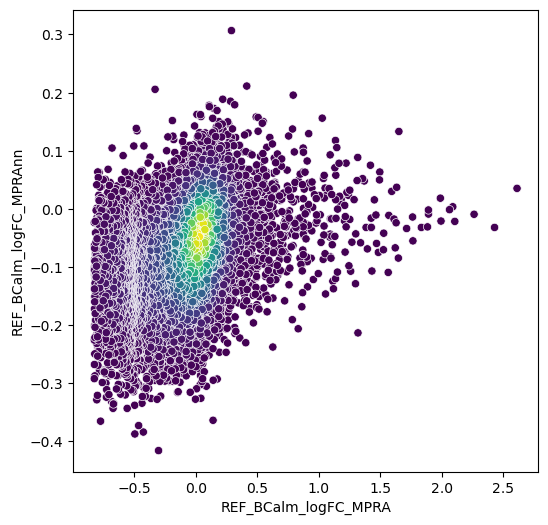

In [48]:
import seaborn as sns
from scipy import stats
# sns.scatterplot(data=correlation_result, x=mpra_column, y=mprann_column)

# # Add KDE plot on top
# sns.kdeplot(data=correlation_result, x=mpra_column, y=mprann_column, cmap="Blues", fill=True, cbar=True)

# plt.show()

values = np.vstack([correlation_result[mpra_column], correlation_result[mprann_column]])
kernel = stats.gaussian_kde(values)(values)
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=correlation_result,
    x=mpra_column,
    y=mprann_column,
    c=kernel,
    cmap="viridis",
    ax=ax,
)


In [ ]:
correlation_result['abs_mpra'] = correlation_result[mpra_column].abs()
correlation_result['abs_mprann'] = correlation_result[mprann_column].abs()

# correlations
spearman_correlation = correlation_result[['abs_mpra', 'abs_mprann']].corr(method='spearman')
pearson_correlation = correlation_result[['abs_mpra', 'abs_mprann']].corr(method='pearson')

# table of correlation:
print('Correlation between absolute values of prediction and measured MPRA activity:\nspearman')
print(spearman_correlation)
print('pearson')
print(pearson_correlation)

print('Compare if the correlation between the absolute values is higher (=> model was able to distingues elements which had influence on the activity if only variants in there => identified influencal effect but not the correct direction)')

Correlation between absolute values of prediction and measured MPRA activity:
spearman
            abs_mpra  abs_mprann
abs_mpra    1.000000    0.174664
abs_mprann  0.174664    1.000000
pearson
            abs_mpra  abs_mprann
abs_mpra     1.00000     0.19859
abs_mprann   0.19859     1.00000


#### Investigate above mean and below mean predictions

In [41]:
print('Investigate correlation above and below mean activity elements')
# filter for above and below mean activity

# Calculate mean and standard deviation
mean_logFC = correlation_result[mpra_column].mean()
std_logFC = correlation_result[mpra_column].std()

# Define upper and lower bounds
upper_bound = mean_logFC + std_logFC/2
lower_bound = mean_logFC - std_logFC/2
print('Mean and Std of the data', mean_logFC)
# Filter the dataframe
elements_highly_active = correlation_result[correlation_result[mpra_column] > upper_bound]
elements_low_activity = correlation_result[correlation_result[mpra_column] < lower_bound]
elements_minimal_active = correlation_result[(correlation_result[mpra_column] < upper_bound) & (correlation_result[mpra_column] > lower_bound)]
print('Highly active elements: ')

# correlations
spearman_correlation = elements_highly_active[[mpra_column, mprann_column]].corr(method='spearman')
pearson_correlation = elements_highly_active[[mpra_column, mprann_column]].corr(method='pearson')

# table of correlation:
print(f'Correlation between prediction and measured MPRA activity of sd/2 above measured mean activity (n:{elements_highly_active.shape[0]}):\nspearman')
print(spearman_correlation)
print('pearson')
print(pearson_correlation)

print('Low active elements: ')

# correlations
spearman_correlation = elements_low_activity[[mpra_column, mprann_column]].corr(method='spearman')
pearson_correlation = elements_low_activity[[mpra_column, mprann_column]].corr(method='pearson')

# table of correlation:
print(f'Correlation between prediction and measured MPRA activity of sd/2 below measured mean activity (n:{elements_low_activity.shape[0]}):\nspearman')
print(spearman_correlation)
print('pearson')
print(pearson_correlation)

print('Elements with minimal activity: ')
# correlations
spearman_correlation = elements_minimal_active[[mpra_column, mprann_column]].corr(method='spearman')
pearson_correlation = elements_minimal_active[[mpra_column, mprann_column]].corr(method='pearson')

# table of correlation:
print(f'Correlation between prediction and measured MPRA activity of around mean activity (n:{elements_minimal_active.shape[0]}):\nspearman')
print(spearman_correlation)
print('pearson')
print(pearson_correlation)

Investigate correlation above and below mean activity elements
Mean and Std of the data -0.06845402884006935
Highly active elements: 
Correlation between prediction and measured MPRA activity of sd/2 above measured mean activity (n:6815):
spearman
                        REF_BCalm_logFC_MPRA  REF_BCalm_logFC_MPRAnn
REF_BCalm_logFC_MPRA                1.000000                0.108412
REF_BCalm_logFC_MPRAnn              0.108412                1.000000
pearson
                        REF_BCalm_logFC_MPRA  REF_BCalm_logFC_MPRAnn
REF_BCalm_logFC_MPRA                1.000000                0.089205
REF_BCalm_logFC_MPRAnn              0.089205                1.000000
Low active elements: 
Correlation between prediction and measured MPRA activity of sd/2 below measured mean activity (n:5848):
spearman
                        REF_BCalm_logFC_MPRA  REF_BCalm_logFC_MPRAnn
REF_BCalm_logFC_MPRA                1.000000                0.077978
REF_BCalm_logFC_MPRAnn              0.077978            